## Inicialización de los datos

In [4]:
# Precarga de todas las librerias necesarias para el proyecto

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from collections import Counter
from pathlib import Path

In [5]:
# Definición de las rutas de los archivos CSV a utilizar en el proyecto 

base_dir = Path().resolve()

data_path_train = base_dir / 'data' / 'gold_recovery_train.csv'
data_path_test = base_dir / 'data' / 'gold_recovery_test.csv'  
data_path_full = base_dir / 'data' / 'gold_recovery_full.csv'

# Lectura y almacenamiento en dataframes de los CVS proporcionados 

au_list = {
    'au_train': pd.read_csv(data_path_train),
    'au_test': pd.read_csv(data_path_test),
    'au_full': pd.read_csv(data_path_full) }


In [6]:
# Consulta de datos generales au_train, au_test, au_full

for name, df in au_list.items(): 
    print(f'++ Forma de la tabla {name}: {df.shape} ++\n')
    print(df.info())
    print('\n','-'*100,'\n')


++ Forma de la tabla au_train: (16860, 87) ++

<class 'pandas.DataFrame'>
RangeIndex: 16860 entries, 0 to 16859
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   date                                                16860 non-null  str    
 1   final.output.concentrate_ag                         16788 non-null  float64
 2   final.output.concentrate_pb                         16788 non-null  float64
 3   final.output.concentrate_sol                        16490 non-null  float64
 4   final.output.concentrate_au                         16789 non-null  float64
 5   final.output.recovery                               15339 non-null  float64
 6   final.output.tail_ag                                16794 non-null  float64
 7   final.output.tail_pb                                16677 non-null  float64
 8   final.output.tail_sol                   

In [7]:
# Impresion de muestra de au_train, au_test, au_full

for df in au_list: display(au_list[df].sample(3))

,date,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
9259,2017-06-05 18:59:59,4.251917,10.636725,8.076898,46.022685,61.144151,8.937325,3.593877,9.165263,3.667957,...,14.974680,-496.825926,9.969688,-379.003796,14.973678,-499.202633,9.993810,-500.127585,14.998421,-500.180405
13156,2018-03-17 03:59:59,4.981612,11.343507,7.925563,44.042980,72.190053,10.007210,2.568092,8.326815,2.762034,...,23.034590,-499.658962,14.964297,-499.602745,18.044661,-499.781130,11.981768,-500.055758,11.978576,-500.129242
6749,2017-02-21 04:59:59,5.813475,10.747704,14.104161,43.976033,73.010765,12.094983,4.189077,8.629817,3.733846,...,24.989349,-399.064774,23.012468,-400.162613,22.998051,-449.256157,19.982860,-449.842581,24.984365,-499.666109


,date,primary_cleaner.input.sulfate,primary_cleaner.input.depressant,primary_cleaner.input.feed_size,primary_cleaner.input.xanthate,primary_cleaner.state.floatbank8_a_air,primary_cleaner.state.floatbank8_a_level,primary_cleaner.state.floatbank8_b_air,primary_cleaner.state.floatbank8_b_level,primary_cleaner.state.floatbank8_c_air,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
4148,2017-10-21 20:59:59,225.958287,13.960422,7.10,1.829708,1699.849346,-499.290150,1700.946299,-486.490115,1654.767808,...,21.000713,-501.216740,19.004196,-401.031767,15.031874,-500.511709,10.980509,-500.103418,16.007900,-500.236458
2003,2016-11-23 11:59:59,196.041197,6.963809,7.38,1.696760,1596.746210,-499.806829,1602.025873,-500.232514,1599.470762,...,18.030640,-501.135997,15.882575,-447.343029,15.395065,-499.946950,11.959839,-500.014192,21.968055,-499.210981
5425,2017-12-14 01:59:59,196.524958,9.989526,8.19,1.100436,1554.171896,-500.106363,1547.485556,-497.016248,1548.260337,...,20.006407,-500.873491,15.048109,-113.572960,10.999067,-499.975324,8.048825,-500.181578,11.990546,-499.904981


,date,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
19629,2018-04-11 20:59:59,3.542927,9.394940,8.080893,49.219810,72.566337,9.225082,2.123326,7.546866,1.859629,...,23.008370,-501.063222,15.939196,-341.002660,17.952079,-499.945497,12.062322,-499.601582,12.996949,-500.068713
1708,2016-03-26 04:00:00,5.108435,8.708830,1.702668,48.109180,62.287500,10.189546,1.233996,18.874992,2.847869,...,11.956652,-500.525189,11.954754,-500.054336,12.039793,-499.542724,10.021443,-499.873688,19.985900,-500.144534
16858,2017-12-17 09:59:59,7.506471,9.247625,8.265027,28.575838,29.950111,9.377262,1.431288,4.904435,4.025224,...,19.957843,-498.201601,16.074490,-44.244302,11.027198,-497.421379,7.997135,-499.712718,12.001879,-499.602975


In [8]:
# Funcion para limpiar dataframes

def wrangling(data):

    '''
    Consulta la cantidad de celdas vacias y duplicadas del dataframe brindado,
    posteriormente se eliminan las filas con estos datos
    '''

    dup = data.duplicated().sum()
    null = data.isna().sum().sum()
    
    if null > 0: data = data.dropna()

    if dup > 0: data.drop_duplicates().reset_index()

    return data
    

In [9]:
# Comprobacion de datos faltantes y duplicados en au_train, au_test, au_full

print(f"** Dataframes sin limpiar")
for name, df in au_list.items():
    print('-'*40)
    print(name)
    print(f'+ Forma de la tabla: {df.shape}\n+ Duplicados: {df.duplicated().sum()}\n+ Celdas vacias: {df.isna().sum().sum()}\n')
    print('-'*40)

# Llamado de la funcion wrangling para limpiar au_train, au_test, au_full

au_list_cl = {name: wrangling(df) for name, df in au_list.items()}

# Confirmacion de limpieza

print(f"** Dataframes limpios")
for name, df in au_list_cl.items():
    print('-'*40)
    print(name)
    print(f'+ Forma de la tabla: {df.shape}\n+ Duplicados: {df.duplicated().sum()}\n+ Celdas vacias: {df.isna().sum().sum()}\n')
    print('-'*40)

** Dataframes sin limpiar
----------------------------------------
au_train
+ Forma de la tabla: (16860, 87)
+ Duplicados: 0
+ Celdas vacias: 30320

----------------------------------------
----------------------------------------
au_test
+ Forma de la tabla: (5856, 53)
+ Duplicados: 0
+ Celdas vacias: 2360

----------------------------------------
----------------------------------------
au_full
+ Forma de la tabla: (22716, 87)
+ Duplicados: 0
+ Celdas vacias: 36587

----------------------------------------
** Dataframes limpios
----------------------------------------
au_train
+ Forma de la tabla: (11017, 87)
+ Duplicados: 0
+ Celdas vacias: 0

----------------------------------------
----------------------------------------
au_test
+ Forma de la tabla: (5383, 53)
+ Duplicados: 0
+ Celdas vacias: 0

----------------------------------------
----------------------------------------
au_full
+ Forma de la tabla: (16094, 87)
+ Duplicados: 0
+ Celdas vacias: 0

----------------------------

## Verificacion del concentrado final de recuperacion mediante calculo manual

In [10]:
# Funcion para calcular el concentrado de recuperacion

def recovery(c, f, t):

    '''
        Aplica la formula de la recuperacion brindada en la documentacion del proyecto
    '''
    
    r = ((c*(f-t))/(f*(c-t)))*100

    return r

In [11]:
# Filtrado de los filas necesarias para el calculo y comparacion

au_train_cl = au_list_cl['au_train']

c = au_train_cl['rougher.output.concentrate_au']
f = au_train_cl['rougher.input.feed_au']
t = au_train_cl['rougher.output.tail_au']

rcy = recovery(c, f, t)

eam = mean_absolute_error(au_train_cl['rougher.output.recovery'], rcy)

print('-'*40)
print(f'Valor EAM de la recuperacion rougher: {eam} \n*Conjunto de entrenamiento vs Calculo manual')
print('-'*40)

----------------------------------------
Valor EAM de la recuperacion rougher: 9.460144184559453e-15 
*Conjunto de entrenamiento vs Calculo manual
----------------------------------------


El valor del EAM arroja que al comparar el valor registrado en el dataframe de entrenamiento y el valor obtenido mediante calculo manual, difieren por una cantidad muy pequeña, podemos confiar en los datos registrados en la base de datos

## Verificacion de columnas faltantes en el dataframe **au_test** 

In [12]:
# Obtencion del nombre de las columnas de au_test y au_full

au_test_col = list(au_list_cl['au_test'].columns)

au_full_col = list(au_list_cl['au_full'].columns)

# Comparacion por medio de un contador

au_miss_in_test = list((Counter(au_full_col) - Counter(au_test_col)).elements())

# Impresion de los resultados

display(au_miss_in_test)

['final.output.concentrate_ag',
 'final.output.concentrate_pb',
 'final.output.concentrate_sol',
 'final.output.concentrate_au',
 'final.output.recovery',
 'final.output.tail_ag',
 'final.output.tail_pb',
 'final.output.tail_sol',
 'final.output.tail_au',
 'primary_cleaner.output.concentrate_ag',
 'primary_cleaner.output.concentrate_pb',
 'primary_cleaner.output.concentrate_sol',
 'primary_cleaner.output.concentrate_au',
 'primary_cleaner.output.tail_ag',
 'primary_cleaner.output.tail_pb',
 'primary_cleaner.output.tail_sol',
 'primary_cleaner.output.tail_au',
 'rougher.calculation.sulfate_to_au_concentrate',
 'rougher.calculation.floatbank10_sulfate_to_au_feed',
 'rougher.calculation.floatbank11_sulfate_to_au_feed',
 'rougher.calculation.au_pb_ratio',
 'rougher.output.concentrate_ag',
 'rougher.output.concentrate_pb',
 'rougher.output.concentrate_sol',
 'rougher.output.concentrate_au',
 'rougher.output.recovery',
 'rougher.output.tail_ag',
 'rougher.output.tail_pb',
 'rougher.output.ta

El listado obtenido arroja solo columnas que contienen valores de "salida" es decir en nuestra base de datos de prueba solo tenemos valores de entrada de cada uno de los procesos. 

## Comparacion de concentraciones en etapa Rougher

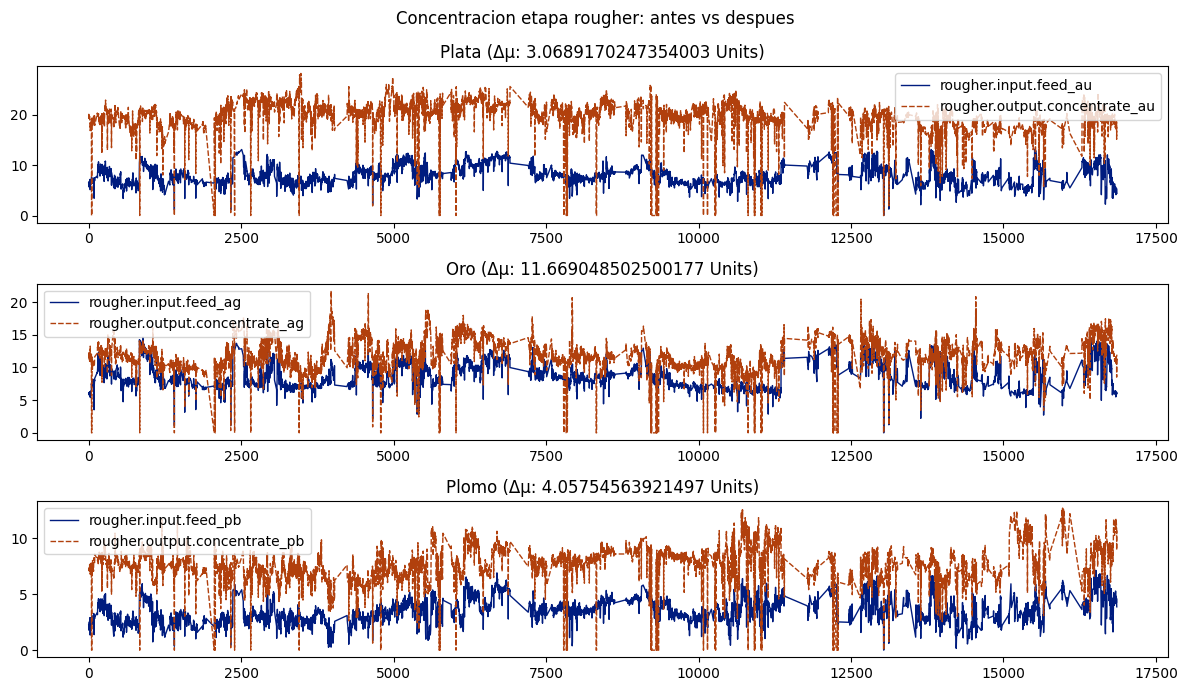

In [13]:
# Dibujado de grafico de lineas para la compracion de los valores de entrada y salida en el proceso rougher 

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=False, sharey=False)
sns.lineplot(data=au_list_cl['au_train'].loc[:,['rougher.input.feed_ag', 'rougher.output.concentrate_ag']], palette="dark", linewidth=1, ax=axes[1])
axes[0].set_title(f"Plata (Δμ: {au_list_cl['au_train'].loc[:,['rougher.output.concentrate_ag']].mean().item()-au_list_cl['au_train'].loc[:,['rougher.input.feed_ag']].mean().item()} Units)")

sns.lineplot(data=au_list_cl['au_train'].loc[:,['rougher.input.feed_au', 'rougher.output.concentrate_au']], palette="dark", linewidth=1, ax=axes[0])
axes[1].set_title(f"Oro (Δμ: {au_list_cl['au_train'].loc[:,['rougher.output.concentrate_au']].mean().item()-au_list_cl['au_train'].loc[:,['rougher.input.feed_au']].mean().item()} Units)")

sns.lineplot(data=au_list_cl['au_train'].loc[:,['rougher.input.feed_pb', 'rougher.output.concentrate_pb']], palette="dark", linewidth=1, ax=axes[2])
axes[2].set_title(f"Plomo (Δμ: {au_list_cl['au_train'].loc[:,['rougher.output.concentrate_pb']].mean().item()-au_list_cl['au_train'].loc[:,['rougher.input.feed_pb']].mean().item()} Units)")

fig.suptitle('Concentracion etapa rougher: antes vs despues')

plt.tight_layout()
plt.show()

En cada uno de los proceso el nivel de concentracion de los elementos involucrados incremeneta, destacando el Oro con un incremento de alrededor de 11 unidades.

## Comparacion del tamaño de particulas de alimentacion: entrenamiento vs prueba

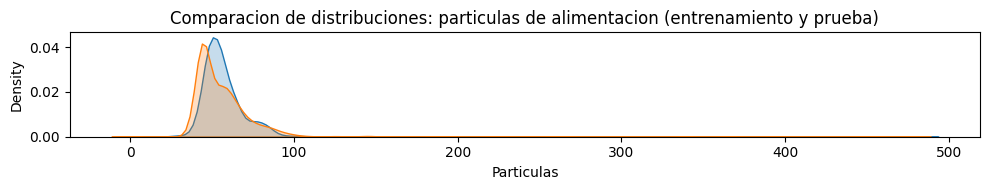

In [14]:
# Construccion de grafico de distribucion con los valores de 'feed_size' en au_train y au_test

fig, ax = plt.subplots(figsize=(10, 2))
sns.kdeplot(au_list_cl['au_train'].loc[:,'rougher.input.feed_size'],fill=True)
sns.kdeplot(au_list_cl['au_test'].loc[:,'rougher.input.feed_size'], fill=True)

ax.set_xlabel("Particulas")

ax.set_title("Comparacion de distribuciones: particulas de alimentacion (entrenamiento y prueba)")

plt.tight_layout()
plt.show()

El grafico nos arroja que el tamaño de las particulas de alimentacion es muy parecido en ambas bases de datos, podemos continuar con el analisis.

## Comparacion de la concentracion total en las etapas de alimentacion, rougher y final

In [15]:
# Funcion de fusion de las concentraciones de cada elemento involucrado en el proceso

def total_concentration(df, prefix):

    '''
        Seleccion de las columnas involucradas, fusion de los valores de las columnas 
    '''
    parts = [f'{prefix}_{m}' for m in ['au','ag','pb','sol'] if f'{prefix}_{m}' in df.columns]
    if parts:
        return df[parts].sum(axis=1)
    return pd.Series(index=df.index, dtype=float)

# Llamado de la funcion total_concentration para la etapa de alimentacion, rougher y final

tot_feed  = total_concentration(au_list['au_full'], 'rougher.input.feed')
tot_rough = total_concentration(au_list['au_full'], 'rougher.output.concentrate')
tot_final = total_concentration(au_list['au_full'], 'final.output.concentrate')

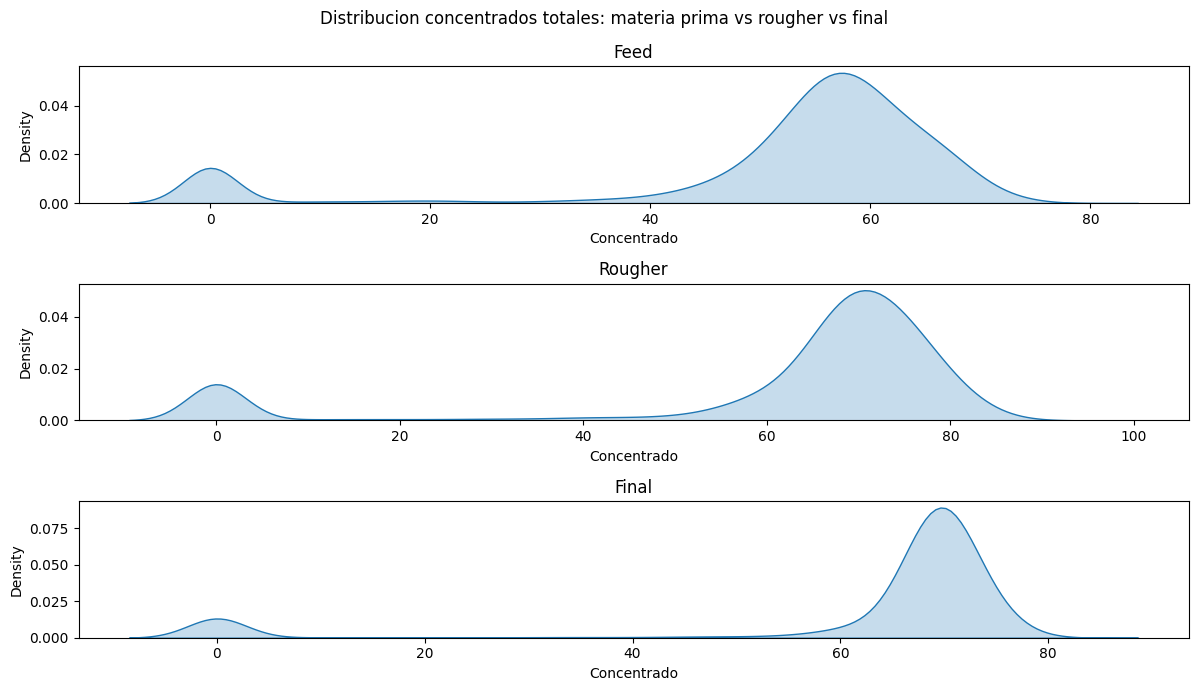

In [16]:
# Graficado de la distribucion de las 3 concentraciones 

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=False, sharey=False)

sns.kdeplot(tot_feed, ax=axes[0], fill=True)
axes[0].set_xlabel("Concentrado"); axes[0].set_title('Feed')

sns.kdeplot(tot_rough, ax=axes[1], fill=True)
axes[1].set_xlabel("Concentrado"); axes[1].set_title('Rougher')

sns.kdeplot(tot_final, ax=axes[2], fill=True)
axes[2].set_xlabel("Concentrado"); axes[2].set_title('Final')

fig.suptitle('Distribucion concentrados totales: materia prima vs rougher vs final')

plt.tight_layout()
plt.show()

En las 3 graficas es notoria la apareicion de valores atipicos, lo ideal seria aislar esos valores para obtener una prediccion mas precisa en nuestros modelos 

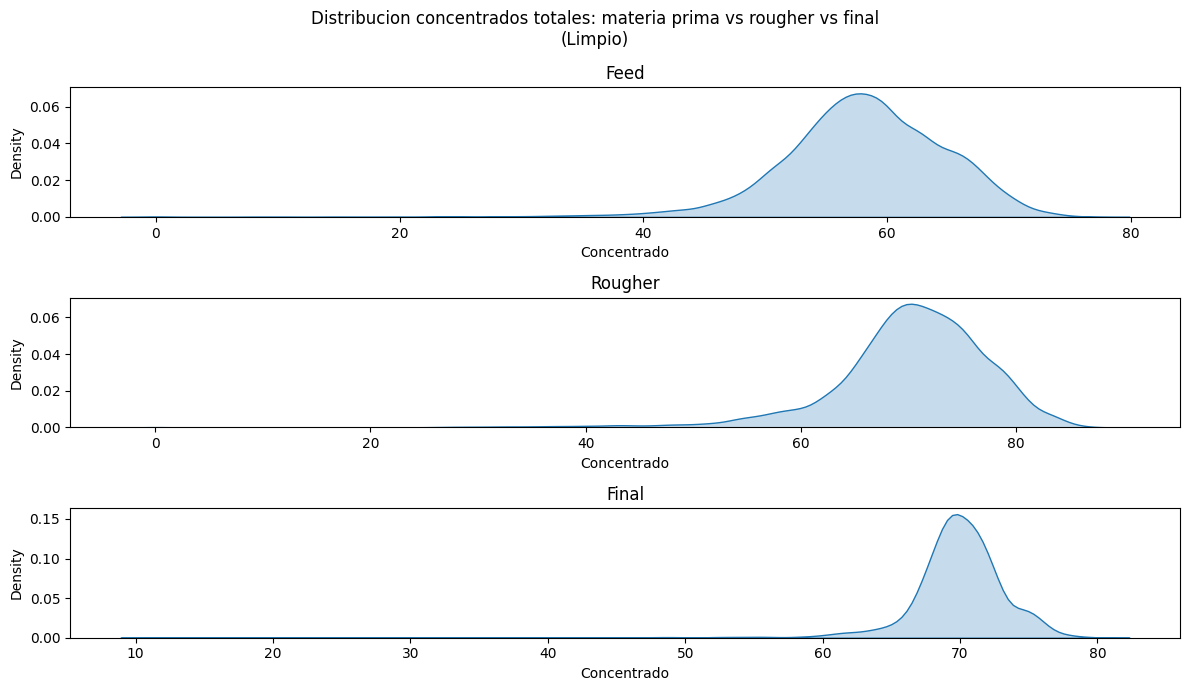

In [17]:
# Funcion para filtrado de indices de os valores atipicos encontrados

def anomaly_mask(df):

    '''
        Filtrado de las columnas para obtener los datos atipicos, 
        obtencion de los indices de dichos datos.
        Regresa: una lista de de indices
    '''
    
    feed  = total_concentration(df, 'rougher.input.feed')
    rough = total_concentration(df, 'rougher.output.concentrate')
    final = total_concentration(df, 'final.output.concentrate')
    mask_bad = pd.Series(False, index=df.index)
    for s in [feed, rough, final]:
        if s is not None and len(s) > 0:
            mask_bad = mask_bad | (s <= 0) 
    return mask_bad

# Llamado de la fucnion 'anomaly_mask' para obtener los indices con valores atipicos

bad_full = anomaly_mask(au_list_cl['au_full'])
bad_train = anomaly_mask(au_list_cl['au_train'])
bad_test  = anomaly_mask(au_list_cl['au_test'])

# filtrado de las bases de datos con los indices obtenidos

full_clean = au_list_cl['au_full'].loc[~bad_full]
train_clean = au_list_cl['au_train'].loc[~bad_train]
test_clean = au_list_cl['au_test'].loc[~bad_test]

# Llamado de las funcion 'total_concentration' sobre las bases de datos limpias

tot_feed_cl  = total_concentration(full_clean, 'rougher.input.feed')
tot_rough_cl = total_concentration(full_clean, 'rougher.output.concentrate')
tot_final_cl = total_concentration(full_clean, 'final.output.concentrate')

# Construccion de graficos de distribucion con los valores limpios

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=False, sharey=False)

sns.kdeplot(tot_feed_cl, ax=axes[0], fill=True)
axes[0].set_xlabel("Concentrado"); axes[0].set_title('Feed')

sns.kdeplot(tot_rough_cl, ax=axes[1], fill=True)
axes[1].set_xlabel("Concentrado"); axes[1].set_title('Rougher')

sns.kdeplot(tot_final_cl, ax=axes[2], fill=True)
axes[2].set_xlabel("Concentrado"); axes[2].set_title('Final')

fig.suptitle('Distribucion concentrados totales: materia prima vs rougher vs final\n(Limpio)')

plt.tight_layout()
plt.show()

Los outiers han desaparecido de los datos, podemos continuar con el modelado.

## Etapa de modelado y evaluacion

### Funcion de modelado y prediccion

In [18]:
# Definicion de funcion para modelado y prediccion 

def train_and_predict(model, features, target_r, target_f, splits, cv=True):

    '''
        Evalua primero el valor de cv; si es verdadero realizara el modelado y validacion cruzada, si no es asi solo realiza el modelado.
        En ambos casos se realiza la evaluacion del paremetro SMAPE (con ayuda de la funcion 'final_smape') del modelo.
        Regresa; 'cv=True' una lista con los valores SMAPE final  de acuerdo a la cantidad de slices en la seire de timepo, 
        para 'cv=False' devuelve los valores de SMAPE final total, SMAPE Rougher y SMAPE etapa final
    '''
    scores = []
    if cv:
        # Creacion de serie de tiempo para validacion cruzada
        tscv = TimeSeriesSplit(n_splits=splits)
        for tr_idx, va_idx in tscv.split(features):
            features_tr, features_va = features.iloc[tr_idx], features.iloc[va_idx]
            target_r_tr, target_r_va = target_r.iloc[tr_idx], target_r.iloc[va_idx]
            target_f_tr, target_f_va = target_f.iloc[tr_idx], target_f.iloc[va_idx]
    
            # Dos modelos independientes por objetivo
            
            model_r_cv = Pipeline([('model', model)]) 
            model_f_cv = Pipeline([('model', model)])
            # Clonar para evitar fuga de estado
            
            import copy
            model_r_cv = copy.deepcopy(model_r_cv)
            model_f_cv = copy.deepcopy(model_f_cv)
            
            # Ajuste
            
            model_r_cv.fit(features_tr, target_r_tr)
            model_f_cv.fit(features_tr, target_f_tr)
            
            # Predicción
            
            pred_r_cv = model_r_cv.predict(features_va)
            pred_f_cv = model_f_cv.predict(features_va)
            
            # sMAPE final
            
            s_final_cv, _, _ = final_smape(target_r_va, pred_r_cv, target_f_va, pred_f_cv)
            scores.append(s_final_cv)
        return scores
    
    else:

        # Division de conjuntos de entrenamiento y validacion

        features_train_r, features_valid_r, target_train_r, target_valid_r = train_test_split(features, target_r, test_size=0.25, random_state=12345)
        features_train_f, features_valid_f, target_train_f, target_valid_f = train_test_split(features, target_f, test_size=0.25, random_state=12345)
        
        model_r = Pipeline([('model', model)])
        model_f = Pipeline([('model', model)])
        
        # Clonar para evitar fuga de estado
        
        import copy
        model_r = copy.deepcopy(model_r)
        model_f = copy.deepcopy(model_f)
        
        # Ajuste
         
        model_r.fit(features_train_r, target_train_r)
        model_f.fit(features_train_f, target_train_f)
        
        # Predicción
         
        pred_r = model_r.predict(features_valid_r)
        pred_f = model_f.predict(features_valid_f)
        
        # sMAPE final total, rougher y final
        
        s_final, s_r, s_f = final_smape(target_valid_r, pred_r, target_valid_f, pred_f)
            
        return s_final, s_r, s_f 


### Funcione de evaluacion de sMAPE

In [20]:
# Creacion de funcion para el calculo del parametro sMAPE

def smape(y_true, y_pred):

    '''
    Calculo del sMAPE. Regresa: valor sMAPE 
    '''

    # Construccion de arreglo con los valores de las columnas agregadas
    
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    # Obtencion de denominador de la forma en valores absolutos
    
    denom = np.abs(y_true) + np.abs(y_pred)

    # Término por elemento; si denom==0 definimos contribución 0
    
    term = np.zeros_like(denom)
    mask = denom > 0

    # Calculo completo de la formula 
    
    term[mask] = 2.0 * np.abs(y_true[mask] - y_pred[mask]) / denom[mask]

    smape_value = term.mean()
    return smape_value * 100

### Funcion de evaluacion de sMAPE final

In [21]:
# Definicion de funcion para sMAPE final de acuerdo a la documentacion de proyecto

def final_smape(y_true_rougher, y_pred_rougher, y_true_final, y_pred_final):

    '''
        Aplicacion de la formula brindada para el sMAPE final, considerando el concentrado rougher y concentrado final.
        Regresa, el valor sMAPE final total, sMAPE concentrado rougher, sMAPE concentrado final 
    '''
    
    s_rougher = smape(y_true_rougher, y_pred_rougher)
    s_final = smape(y_true_final,   y_pred_final)
    return 0.25 * s_rougher + 0.75 * s_final, s_rougher, s_final


### Recuperacion de los resultados